In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [15]:
def process_log_file(log_dir, gamma=0.99, lam=0.95):
    actions = []
    rewards = []
    cumulative_rewards = []
    discount_power = 1  
    discounted_return = 0
    
    try:
        with open(log_dir, "r") as file:
            for line in file:
                line = line.strip()
                
                if line.startswith("Action:"):
                    action_values = [float(x) for x in line.split("[")[1].split("]")[0].split()]
                    actions.append(action_values)
                
                elif line.startswith("Reward:"):
                    reward_value = float(line.split("Reward:")[1].strip())
                    rewards.append(reward_value)
                    discounted_return += reward_value * discount_power
                    discount_power *= gamma  # Apply discounting
                    cumulative_rewards.append(sum(rewards))
        
        # Convert actions to a 2D numpy array
        actions_array = np.array(actions)
        
        # Plot reward over time
        plt.figure(figsize=(15, 7))
        plt.plot(range(len(rewards)), rewards, label="Reward per step")
        plt.xlabel("Time Step")
        plt.ylabel("Reward")
        plt.title("Reward vs Time")
        plt.legend()
        plt.grid()
        plt.show()
        # plt.savefig("reward_vs_time.png")
        # plt.close()
        
        # Plot action pairs over time
        plt.figure(figsize=(15, 7))
        plt.plot(range(len(actions_array)), actions_array[:, 0], label="Action 1")
        plt.plot(range(len(actions_array)), actions_array[:, 1], label="Action 2")
        plt.xlabel("Time Step")
        plt.ylabel("Action Value")
        plt.title("Actions vs Time")
        plt.legend()
        plt.grid()
        plt.show()
        # plt.savefig("actions_vs_time.png")
        
        print(f"Plots saved: reward_vs_time.png, actions_vs_time.png")
        print(f"Cumulative Reward: {cumulative_rewards[-1]}")
        print(f"Discounted Return: {discounted_return}")
        print(f"Stored Actions Shape: {actions_array.shape}")
        
        # return cumulative_rewards, discounted_return, actions_array
    
    except Exception as e:
        print(f"Error processing file: {e}")
        # return None, None, None

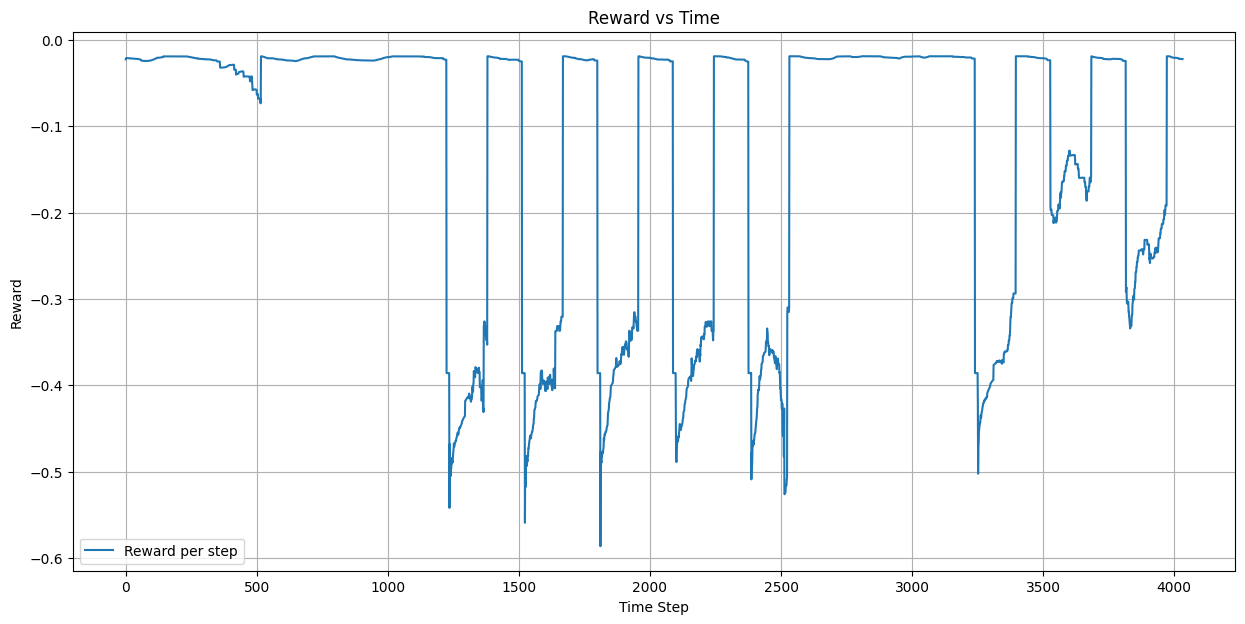

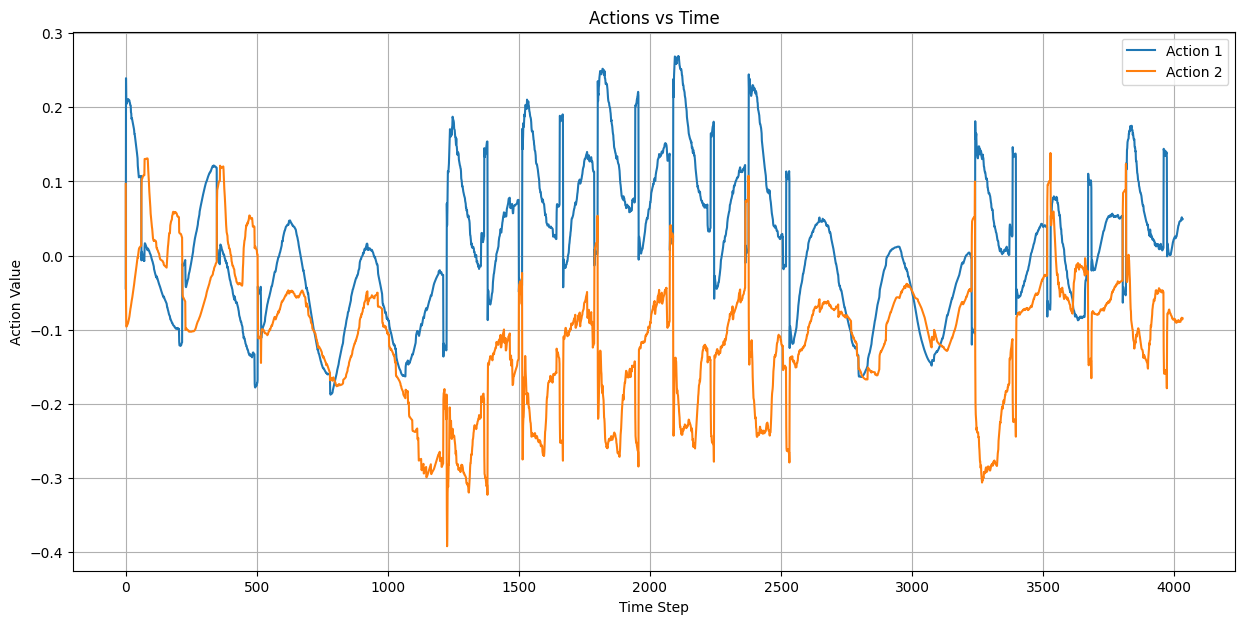

Plots saved: reward_vs_time.png, actions_vs_time.png
Cumulative Reward: -496.3202027287334
Discounted Return: -2.204154882522955
Stored Actions Shape: (4033, 2)


In [18]:
process_log_file("PPO_Eval/episode_data.txt")

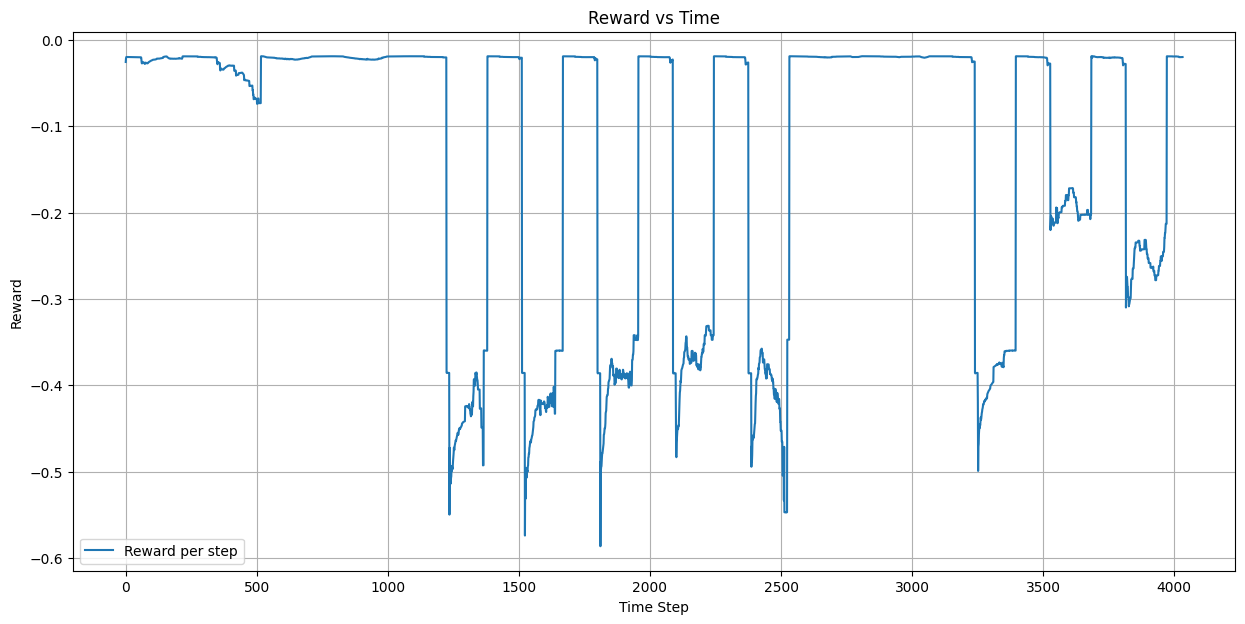

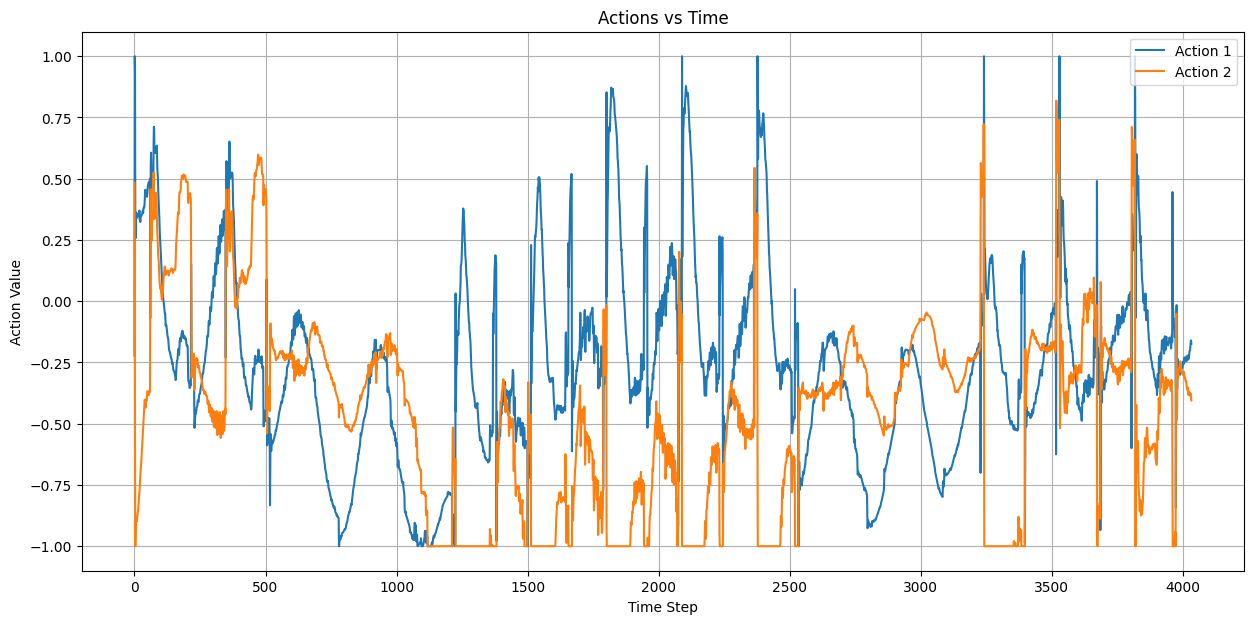

Plots saved: reward_vs_time.png, actions_vs_time.png
Cumulative Reward: -508.1914054118097
Discounted Return: -2.179719850589142
Stored Actions Shape: (4033, 2)


In [17]:
process_log_file("PPO_Eval_Scale/episode_data.txt")